# $(SASA) Models - Kmodels$

In [1]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
import pickle
import numpy as np
import pandas as pd

from pmbrl.model2 import Base_Line_Simple_Model
# from pmbrl.model2 import Model, Regularized_Reference_Loss
from pmbrl.data import Experiment_Data, get_data_expanded

In [2]:
data = Experiment_Data()

data.load(path='../training_data.csv')
data.build_training_dataset()

,step,episode,p,s,a,r,s_,a_,r_,s__
2141,7,83,"(0.386432698550154, 0.8914088207818202)","(-0.013, 0.528, -0.001, -0.626)",1,1.0,"(-0.003, 0.719, -0.014, -0.834)",1.0,1.0,"(0.012, 0.91, -0.03, -1.045)"
1114,12,46,"(0.5759890361457483, 0.539204361971833)","(0.055, 0.363, -0.076, -0.902)",0,1.0,"(0.062, 0.164, -0.094, -0.522)",1.0,1.0,"(0.065, 0.366, -0.104, -0.976)"
1218,11,50,"(0.3156324259991037, 0.4950654122165437)","(0.064, 0.235, -0.039, -0.391)",1,1.0,"(0.069, 0.433, -0.047, -0.756)",0.0,1.0,"(0.077, 0.237, -0.062, -0.424)"
1919,0,77,"(0.1064004661572971, 0.3173964772630564)","(0.029, 0.005, -0.026, -0.017)",1,1.0,"(0.029, 0.209, -0.026, -0.492)",0.0,1.0,"(0.033, 0.006, -0.036, -0.042)"
1306,28,53,"(0.2444473003074412, 0.4846825463128728)","(0.009, -0.368, -0.044, 0.612)",1,1.0,"(0.002, -0.17, -0.032, 0.259)",0.0,1.0,"(-0.001, -0.366, -0.027, 0.585)"
...,...,...,...,...,...,...,...,...,...,...
1414,29,57,"(0.4858968354133477, 0.4002511587990111)","(-0.104, -0.593, 0.126, 0.958)",1,1.0,"(-0.116, -0.391, 0.145, 0.525)",1.0,1.0,"(-0.124, -0.19, 0.156, 0.104)"
2348,12,93,"(0.2048148528652186, 0.3945260327599418)","(0.049, 0.401, 0.002, -0.723)",0,1.0,"(0.057, 0.2, -0.012, -0.32)",0.0,1.0,"(0.061, 0.001, -0.019, 0.076)"
1857,26,73,"(0.1621684058210441, 0.4843613270065507)","(0.007, 0.356, 0.017, -0.218)",1,1.0,"(0.014, 0.552, 0.013, -0.529)",1.0,1.0,"(0.025, 0.748, 0.002, -0.841)"
1388,3,57,"(0.4858968354133477, 0.4002511587990111)","(0.03, 0.609, 0.004, -1.493)",0,1.0,"(0.043, 0.404, -0.026, -0.981)",0.0,1.0,"(0.051, 0.2, -0.046, -0.486)"


In [3]:
expansions = {
    's': ['s0', 's1', 's2', 's3'],
    's_': ['s_0', 's_1', 's_2', 's_3'],
    'p': ['p0', 'p1'],
}

df = get_data_expanded(data.build_training_dataset(), expansions)
# df = df.loc[df['episode']<15].copy()
df

,step,episode,p,s,a,r,s_,a_,r_,s__,s0,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1
1623,11,66,"(0.0609425168772551, 1.2010637267216533)","(-0.069, -0.915, 0.028, 0.566)",1,1.0,"(-0.087, -0.728, 0.039, 0.451)",1.0,1.0,"(-0.102, -0.541, 0.048, 0.338)",-0.069,-0.915,0.028,0.566,-0.087,-0.728,0.039,0.451,0.060943,1.201064
1698,20,67,"(0.0550547819736606, 0.7277451834527079)","(-0.123, -0.424, 0.101, 0.488)",1,1.0,"(-0.131, -0.234, 0.111, 0.315)",1.0,1.0,"(-0.136, -0.045, 0.117, 0.145)",-0.123,-0.424,0.101,0.488,-0.131,-0.234,0.111,0.315,0.055055,0.727745
1844,13,73,"(0.1621684058210441, 0.4843613270065507)","(-0.053, -0.218, 0.06, 0.405)",1,1.0,"(-0.057, -0.022, 0.068, 0.11)",0.0,1.0,"(-0.057, -0.22, 0.07, 0.449)",-0.053,-0.218,0.060,0.405,-0.057,-0.022,0.068,0.110,0.162168,0.484361
131,15,6,"(0.2451557536988955, 1.3793967951445396)","(-0.012, 0.547, -0.012, -0.383)",0,1.0,"(-0.001, 0.359, -0.02, -0.265)",1.0,1.0,"(0.006, 0.547, -0.025, -0.387)",-0.012,0.547,-0.012,-0.383,-0.001,0.359,-0.020,-0.265,0.245156,1.379397
1158,56,46,"(0.5759890361457483, 0.539204361971833)","(-0.266, 0.354, 0.086, -0.712)",1,1.0,"(-0.259, 0.553, 0.072, -1.086)",0.0,1.0,"(-0.248, 0.351, 0.05, -0.64)",-0.266,0.354,0.086,-0.712,-0.259,0.553,0.072,-1.086,0.575989,0.539204
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,1,65,"(0.1785778102029531, 1.438381745613701)","(-0.045, -0.185, -0.013, 0.079)",0,1.0,"(-0.049, -0.371, -0.011, 0.186)",1.0,1.0,"(-0.056, -0.185, -0.008, 0.076)",-0.045,-0.185,-0.013,0.079,-0.049,-0.371,-0.011,0.186,0.178578,1.438382
2486,5,98,"(0.070057487794809, 0.3145540971768632)","(0.024, -0.569, 0.006, 1.271)",1,1.0,"(0.012, -0.367, 0.031, 0.819)",0.0,1.0,"(0.005, -0.57, 0.048, 1.289)",0.024,-0.569,0.006,1.271,0.012,-0.367,0.031,0.819,0.070057,0.314554
521,73,19,"(0.0642916329828742, 1.239005358213764)","(0.19, 0.95, 0.127, -0.004)",1,1.0,"(0.209, 1.136, 0.127, -0.103)",0.0,1.0,"(0.232, 0.948, 0.125, 0.027)",0.190,0.950,0.127,-0.004,0.209,1.136,0.127,-0.103,0.064292,1.239005
379,25,13,"(0.2403247570594251, 0.7298838219922094)","(0.122, -0.539, -0.038, 0.607)",1,1.0,"(0.112, -0.346, -0.026, 0.374)",1.0,1.0,"(0.105, -0.154, -0.019, 0.144)",0.122,-0.539,-0.038,0.607,0.112,-0.346,-0.026,0.374,0.240325,0.729884


# Initialization by Random Partitioning

In [4]:
k = 5
models = [Base_Line_Simple_Model() for _ in range(k)]
params = [1/k for _ in range(k)]

In [5]:
groups = np.random.randint(low=0, high=k, size=df.episode.unique().shape[0])
df['group'] = np.nan

for i, g in enumerate(groups):
    df.loc[df['episode']==i,'group'] = g
df

,step,episode,p,s,a,r,s_,a_,r_,s__,...,s1,s2,s3,s_0,s_1,s_2,s_3,p0,p1,group
1623,11,66,"(0.0609425168772551, 1.2010637267216533)","(-0.069, -0.915, 0.028, 0.566)",1,1.0,"(-0.087, -0.728, 0.039, 0.451)",1.0,1.0,"(-0.102, -0.541, 0.048, 0.338)",...,-0.915,0.028,0.566,-0.087,-0.728,0.039,0.451,0.060943,1.201064,4.0
1698,20,67,"(0.0550547819736606, 0.7277451834527079)","(-0.123, -0.424, 0.101, 0.488)",1,1.0,"(-0.131, -0.234, 0.111, 0.315)",1.0,1.0,"(-0.136, -0.045, 0.117, 0.145)",...,-0.424,0.101,0.488,-0.131,-0.234,0.111,0.315,0.055055,0.727745,0.0
1844,13,73,"(0.1621684058210441, 0.4843613270065507)","(-0.053, -0.218, 0.06, 0.405)",1,1.0,"(-0.057, -0.022, 0.068, 0.11)",0.0,1.0,"(-0.057, -0.22, 0.07, 0.449)",...,-0.218,0.060,0.405,-0.057,-0.022,0.068,0.110,0.162168,0.484361,2.0
131,15,6,"(0.2451557536988955, 1.3793967951445396)","(-0.012, 0.547, -0.012, -0.383)",0,1.0,"(-0.001, 0.359, -0.02, -0.265)",1.0,1.0,"(0.006, 0.547, -0.025, -0.387)",...,0.547,-0.012,-0.383,-0.001,0.359,-0.020,-0.265,0.245156,1.379397,0.0
1158,56,46,"(0.5759890361457483, 0.539204361971833)","(-0.266, 0.354, 0.086, -0.712)",1,1.0,"(-0.259, 0.553, 0.072, -1.086)",0.0,1.0,"(-0.248, 0.351, 0.05, -0.64)",...,0.354,0.086,-0.712,-0.259,0.553,0.072,-1.086,0.575989,0.539204,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1579,1,65,"(0.1785778102029531, 1.438381745613701)","(-0.045, -0.185, -0.013, 0.079)",0,1.0,"(-0.049, -0.371, -0.011, 0.186)",1.0,1.0,"(-0.056, -0.185, -0.008, 0.076)",...,-0.185,-0.013,0.079,-0.049,-0.371,-0.011,0.186,0.178578,1.438382,2.0
2486,5,98,"(0.070057487794809, 0.3145540971768632)","(0.024, -0.569, 0.006, 1.271)",1,1.0,"(0.012, -0.367, 0.031, 0.819)",0.0,1.0,"(0.005, -0.57, 0.048, 1.289)",...,-0.569,0.006,1.271,0.012,-0.367,0.031,0.819,0.070057,0.314554,2.0
521,73,19,"(0.0642916329828742, 1.239005358213764)","(0.19, 0.95, 0.127, -0.004)",1,1.0,"(0.209, 1.136, 0.127, -0.103)",0.0,1.0,"(0.232, 0.948, 0.125, 0.027)",...,0.950,0.127,-0.004,0.209,1.136,0.127,-0.103,0.064292,1.239005,4.0
379,25,13,"(0.2403247570594251, 0.7298838219922094)","(0.122, -0.539, -0.038, 0.607)",1,1.0,"(0.112, -0.346, -0.026, 0.374)",1.0,1.0,"(0.105, -0.154, -0.019, 0.144)",...,-0.539,-0.038,0.607,0.112,-0.346,-0.026,0.374,0.240325,0.729884,0.0


## Initial Training 

In [6]:
def train_models(models, train_dataset):
    train_data = [None for _ in models]

    for g, model in enumerate(models):
        # print('train model: ', g)
        group_data = train_dataset.loc[train_dataset['group']==g]
        if group_data.shape[0] > 0:
            x, y = model.get_features_targets(group_data)
            trainer = model.train(x, y, num_epochs=1000)
            train_data[g] = data.get_training_data(trainer, inference_schema=model.inference_schema)
    
    return train_data


In [7]:
train_data = train_models(models, df[[
    's', 's_', 's__', 'a', 'a_', 'r', 'p', 'group'
]])

train_data[0].head()

,epoch,mse_s,transition,reward
0,0,"[0.06770709902048111, 0.3345213830471039, 0.10...",1.085441,1.899186
1,1,"[0.06605003774166107, 0.3315955400466919, 0.09...",1.071783,1.891721
2,2,"[0.06442777812480927, 0.3286881446838379, 0.09...",1.058271,1.884316
3,3,"[0.06284062564373016, 0.3257990777492523, 0.09...",1.044907,1.876974
4,4,"[0.06128881499171257, 0.32292836904525757, 0.0...",1.031691,1.869699


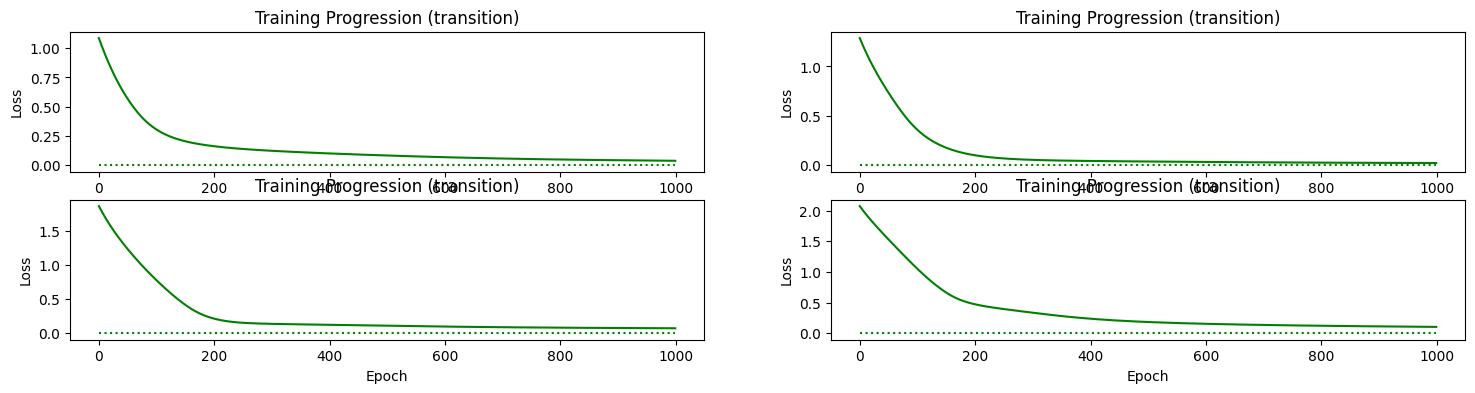

In [8]:
fig, axs = plt.subplots(2, 2, figsize=(18, 4))

data.plot_training_loss(axs[0][0], train_data[0].transition)
data.plot_training_loss(axs[0][1], train_data[1].transition)
data.plot_training_loss(axs[1][0], train_data[2].transition)
data.plot_training_loss(axs[1][1], train_data[3].transition)

plt.show()

# Predict 

In [9]:
def evaluate(models, params, df):
    def predict(model):
        prediction_dataset = df.copy()
        prediction_dataset[model.grouped_targets_lables] = prediction_dataset.apply(lambda row: data._predict_from_row(row, model), axis=1, result_type='expand')
        return prediction_dataset

    predictions = [predict(m) for m in models]

    prediction_dataset = df.copy()
    for i, pred in enumerate(predictions):
        prediction_dataset[f'estimated_s_model_{i}'] = pred['estimated_s']
        prediction_dataset[f'pram_{i}'] = params[i]
        pred['estimated_s'] = pred['estimated_s'].apply(lambda x: [n*params[i] for n in x])
        
        results = data.get_evaluation_metrics(pred, p=False)
        prediction_dataset[f'rse_model_{i}'] = results['rse']
        prediction_dataset[f'rse_normalized_model_{i}'] = results['rse_normalized']

        prediction_dataset[f'rse_s0_model_{i}'] = results['rse_s0']
        prediction_dataset[f'rse_s1_model_{i}'] = results['rse_s1']
        prediction_dataset[f'rse_s2_model_{i}'] = results['rse_s2']
        prediction_dataset[f'rse_s3_model_{i}'] = results['rse_s3']

        prediction_dataset[f'rse_s0_normalized_model_{i}'] = results['rse_s0_normalized']
        prediction_dataset[f'rse_s1_normalized_model_{i}'] = results['rse_s1_normalized']
        prediction_dataset[f'rse_s2_normalized_model_{i}'] = results['rse_s2_normalized']
        prediction_dataset[f'rse_s3_normalized_model_{i}'] = results['rse_s3_normalized']


    return prediction_dataset

In [10]:
prediction_dataset = evaluate(models, params, df)
prediction_dataset.head()

,step,episode,p,s,a,r,s_,a_,r_,s__,...,rse_model_4,rse_normalized_model_4,rse_s0_model_4,rse_s1_model_4,rse_s2_model_4,rse_s3_model_4,rse_s0_normalized_model_4,rse_s1_normalized_model_4,rse_s2_normalized_model_4,rse_s3_normalized_model_4
1623,11,66,"(0.0609425168772551, 1.2010637267216533)","(-0.069, -0.915, 0.028, 0.566)",1,1.0,"(-0.087, -0.728, 0.039, 0.451)",1.0,1.0,"(-0.102, -0.541, 0.048, 0.338)",...,0.8568,0.532142,0.0776,0.4346,0.0450,0.2996,0.435720,0.494790,0.606715,0.591343
1698,20,67,"(0.0550547819736606, 0.7277451834527079)","(-0.123, -0.424, 0.101, 0.488)",1,1.0,"(-0.131, -0.234, 0.111, 0.315)",1.0,1.0,"(-0.136, -0.045, 0.117, 0.145)",...,0.3590,0.545411,0.1032,0.0330,0.0962,0.1266,0.446378,0.424813,0.729496,0.580958
1844,13,73,"(0.1621684058210441, 0.4843613270065507)","(-0.053, -0.218, 0.06, 0.405)",1,1.0,"(-0.057, -0.022, 0.068, 0.11)",0.0,1.0,"(-0.057, -0.22, 0.07, 0.449)",...,0.6256,0.525460,0.0430,0.1680,0.0578,0.3568,0.421316,0.448336,0.637410,0.594777
131,15,6,"(0.2451557536988955, 1.3793967951445396)","(-0.012, 0.547, -0.012, -0.383)",0,1.0,"(-0.001, 0.359, -0.02, -0.265)",1.0,1.0,"(0.006, 0.547, -0.025, -0.387)",...,0.7302,0.512138,0.0014,0.4354,0.0256,0.2678,0.403997,0.494929,0.560192,0.589435
1158,56,46,"(0.5759890361457483, 0.539204361971833)","(-0.266, 0.354, 0.086, -0.712)",1,1.0,"(-0.259, 0.553, 0.072, -1.086)",0.0,1.0,"(-0.248, 0.351, 0.05, -0.64)",...,0.9976,0.540897,0.1910,0.2848,0.0464,0.4754,0.482931,0.468688,0.610072,0.601897


In [11]:
def reagroup(prediction_dataset):
    agg_results = prediction_dataset[['episode'] + [
    f'rse_model_{i}' for i,_ in enumerate(models)
    #     'rse_model_0',
    #     'rse_model_1',
    #     'rse_model_2',
    #     'rse_model_3',
    #     'rse_model_4',
    ]].groupby('episode').mean().reset_index()

    agg_results['best_model'] = agg_results.apply(lambda row: np.argmin(row[1:].values), axis=1)
    print(agg_results['best_model'].value_counts())

    prediction_dataset['best_model'] = prediction_dataset.apply(lambda row: agg_results[agg_results['episode']==row['episode']].best_model.values[0],axis=1)
    prediction_dataset['best_rse'] = prediction_dataset.apply(lambda row: row[f'rse_model_{row.best_model}'],axis=1)

    return prediction_dataset

In [12]:
prediction_dataset = reagroup(prediction_dataset)
prediction_dataset[['best_rse']].describe()

best_model
3    49
1    28
4    16
0     7
Name: count, dtype: int64


,best_rse
count,2504.000000
mean,1.052383
std,0.875950
min,0.029400
25%,0.451150
50%,0.819300
75%,1.404600
max,9.313600


In [13]:
def optimize_params(prediction_dataset):
    expansions = {f'estimated_s_model_{i}': [f's0_{i}', f's1_{i}', f's2_{i}', f's3_{i}'] for i, _ in enumerate(models)}
    expansions.update({'s__': ['s_0', 's_1', 's_2', 's_3']})
    df = get_data_expanded(prediction_dataset, expansions)
    df['A'] = df.apply(lambda row: np.array([[row[f's{d}_{m}'] for m,_ in enumerate(models)] for d in range(4)]),axis=1)
    df['b'] = df.apply(lambda row: np.array([row[f's_{d}'] for d in range(4)]),axis=1)
    df['w'] = df.apply(lambda row: np.linalg.lstsq(row.A, row.b)[0],axis=1)
    return df.w.to_numpy().mean().tolist()

params = optimize_params(prediction_dataset)

# LOOP

In [14]:

# while True: 
for _ in range(10): 
    check = prediction_dataset[prediction_dataset['group'] != prediction_dataset['best_model']].shape[0]
    print(f'epis_changed: {check}')
    if check == 0:
        break
    
    train_df = prediction_dataset[['s', 's_', 's__', 'a', 'a_', 'r', 'p']].copy()
    train_df['group'] = prediction_dataset['best_model']
    train_data = train_models(models, train_df)

    prediction_dataset = evaluate(models, params, prediction_dataset)
    prediction_dataset = reagroup(prediction_dataset)
    params = optimize_params(prediction_dataset)

    print(prediction_dataset[['best_rse']].mean())
    

epis_changed: 1936
best_model
4    98
3     2
Name: count, dtype: int64
best_rse    0.793644
dtype: float64
epis_changed: 2005
best_model
4    96
3     4
Name: count, dtype: int64
best_rse    0.870571
dtype: float64
epis_changed: 2005
best_model
4    100
Name: count, dtype: int64


KeyboardInterrupt: 